In [98]:
%load_ext autoreload
%autoreload 2

import os
import glob
import sys
sys.path.insert(0, "../")

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# %matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [99]:
# df = pd.read_csv('observe_FingerFlexionECoG.csv')
df = pd.read_csv('observe_SynchrophasorEventsLarge.csv')

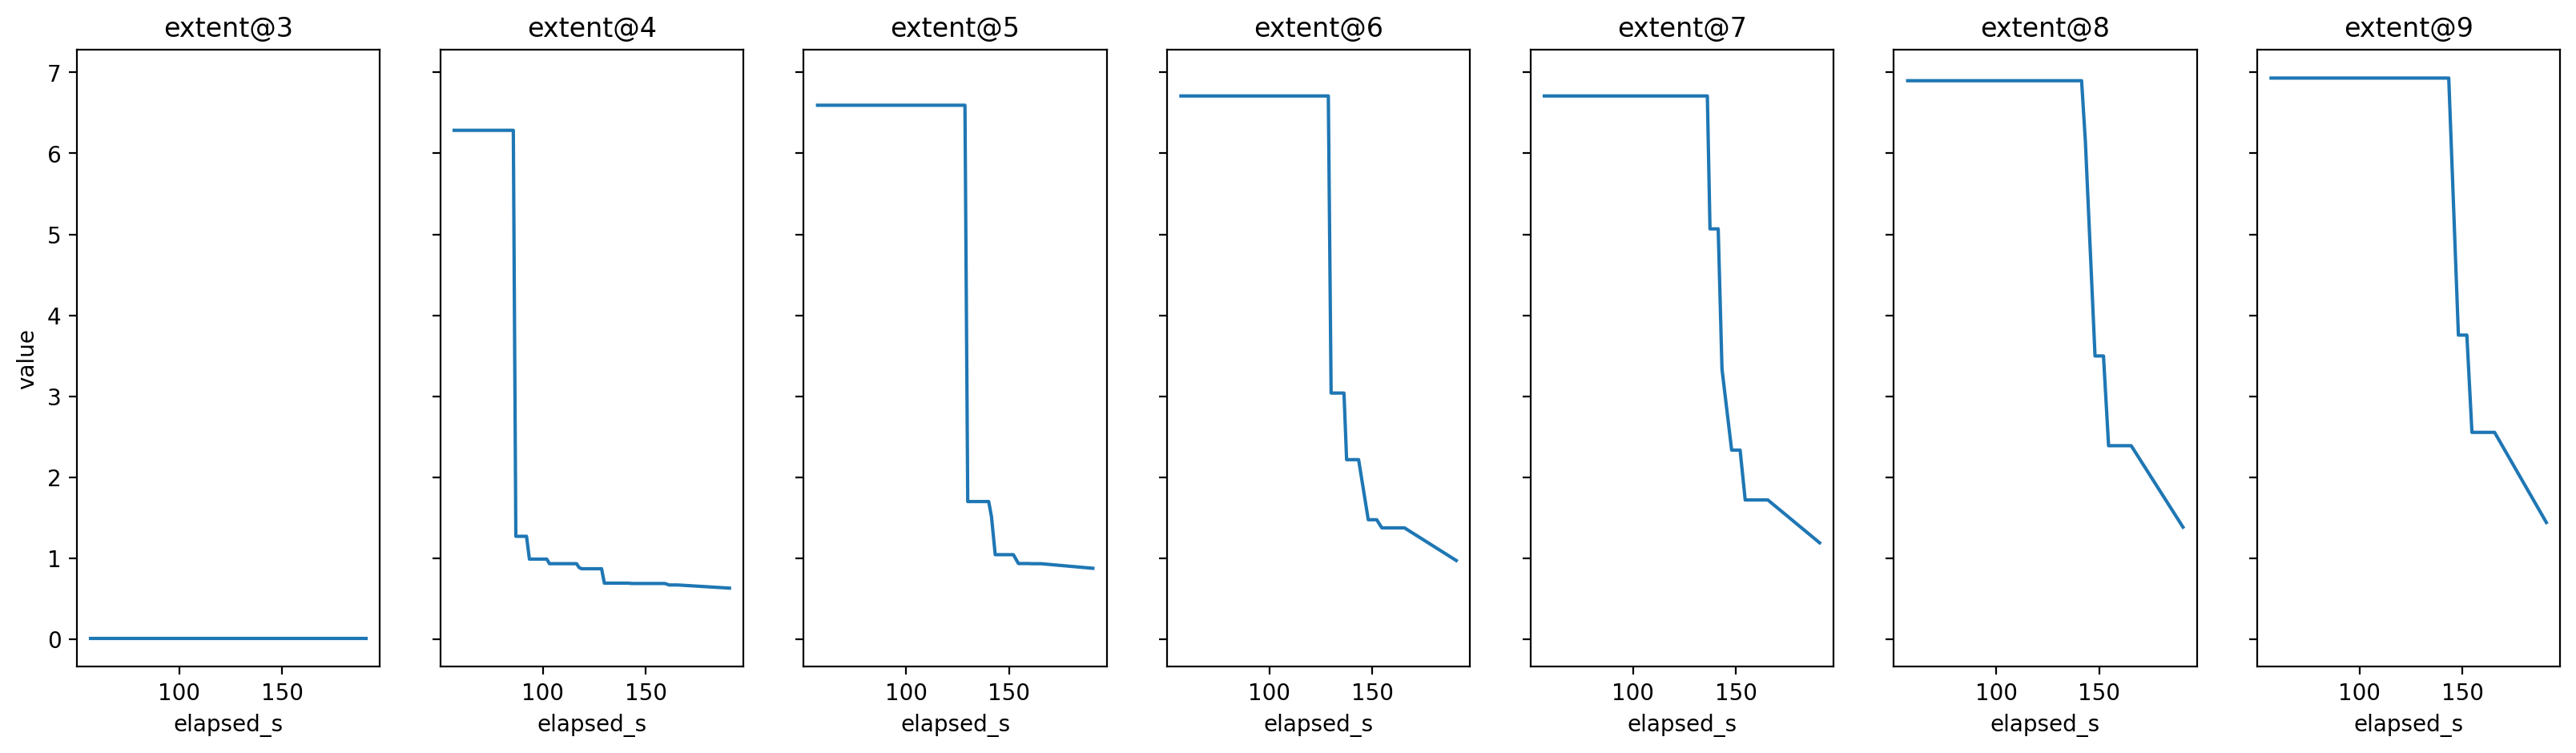

In [100]:
fig, ax = plt.subplots(1, 7, figsize=(20,5), sharey=True)
for i in range(3, 10):
    df_k = df[df.name == f"extent@{i}"]
    sns.lineplot(data=df_k, x="elapsed_s", y="value", ax = ax[i-3])
    ax[i-3].set_title(f"extent@{i}")
plt.show()

In [101]:
df_k

,elapsed_s,repetition,prefix,name,value
286,56.987912,0,8,extent@9,6.929545
566,58.963297,1,8,extent@9,6.929545
597,61.106872,2,8,extent@9,6.929545
869,63.295374,3,8,extent@9,6.929545
1137,65.517207,4,8,extent@9,6.929545
...,...,...,...,...,...
23121,157.596045,6,2,extent@9,2.556201
25722,159.271280,7,2,extent@9,2.556201
27038,161.354784,8,2,extent@9,2.556201
32209,165.538353,9,2,extent@9,2.556201


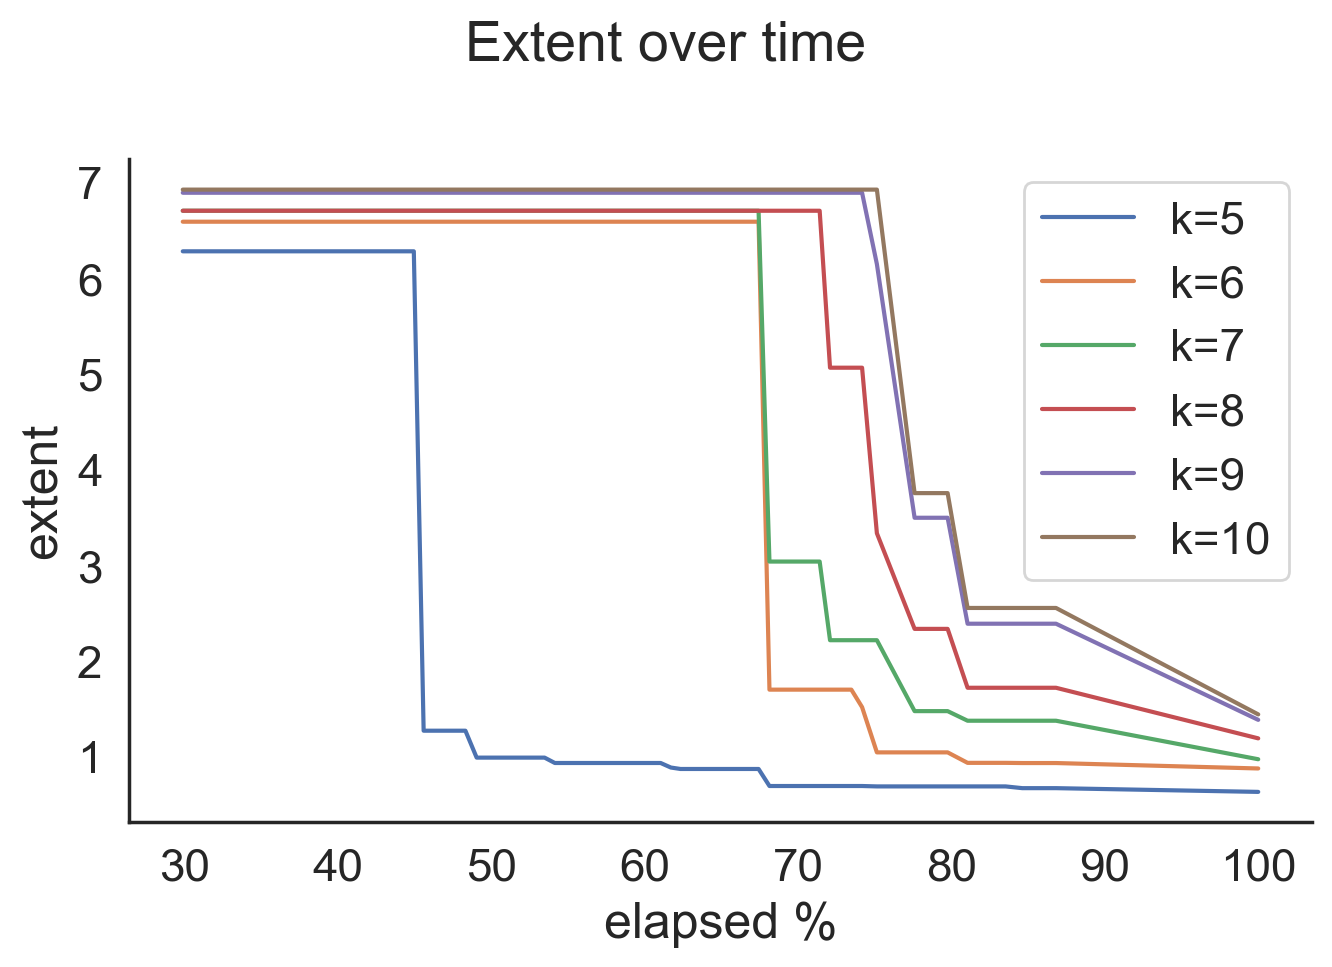

In [161]:
df_k = df_k.copy()
# display(df_k)

# Set white background and font scale
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
sns.set(font_scale=1.5, style='white')


fig, ax = plt.subplots(1, 1, figsize=(7, 5), sharey=True)
for i in range(4, 10):
    df_k = df[df.name == f"extent@{i}"].copy()
    df_k.rename(columns={"value":"extent"}, inplace=True)
    df_k["elapsed %"] = df_k[["elapsed_s"]].transform(lambda l: l *100 / l.max())
    sns.lineplot(data=df_k, x="elapsed %", y="extent", ax = ax, label=f"k={i+1}")
    ax.legend()
sns.despine()
fig.suptitle("Extent over time", fontsize=20)
plt.tight_layout()
fig.savefig("images/anytime.pdf", bbox_inches='tight', facecolor='white')
plt.show()
